In [1]:
import scanpy as sc
import anndata as an
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from typing import Optional, Union
import seaborn as sns
import scipy
from scipy.spatial import distance
from scipy.spatial.distance import cdist
from scipy import stats
from bisect import bisect_left
from scipy.interpolate import interp1d

# Model Setup

## βVAE model

In [2]:
class TimeSeriesVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=15):
        super(TimeSeriesVAE, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2)
        )
        
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, input_dim),
            nn.Sigmoid()
        )
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def encode(self, x):
        enc = self.encoder(x)
        mu = self.fc_mu(enc)
        logvar = self.fc_logvar(enc)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        z, mu, logvar = self.encode(x)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

In [3]:
def vae_loss(recon_x, x, mu, logvar, beta=0.5):
    BCE = nn.functional.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + beta * KLD

In [4]:
def train_vae(model, dataloader, epochs=100, lr=1e-4):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for data in dataloader:
            data = data[0].to(device)
            optimizer.zero_grad()
            
            recon_batch, mu, logvar = model(data)
            loss = vae_loss(recon_batch, data, mu, logvar)
            
            loss.backward()
            train_loss += loss.item()
            optimizer.step()
        
        avg_loss = train_loss / len(dataloader.dataset)
        if (epoch+1) % 10 == 0:
            print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')
    
    return model

In [5]:
def save_model(model, adata, model_path='sc_vae_model.pth'):
    
    torch.save({
        'model_state_dict': model.state_dict(),
        'input_dim': model.encoder[0].in_features, 
        'latent_dim': model.fc_mu.out_features
        }, model_path)
    
def load_model(model_path='sc_vae_model.pth', device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    checkpoint = torch.load(model_path, map_location=device)
    
    model = TimeSeriesVAE(
        input_dim=checkpoint['input_dim'],
        latent_dim=checkpoint['latent_dim']
    )
    
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    print(f"loading model from {model_path}")
    print(f"input dim: {checkpoint['input_dim']}, latent dim: {checkpoint['latent_dim']}")
    
    return model

## Correction

In [6]:
def reduce_total_expression(matrix, target_sum=10000):
    matrix = matrix.T
    result_matrix = np.zeros_like(matrix)
    
    for j in range(matrix.shape[1]): 
        cell_data = matrix[:, j]
        
        sorted_indices = np.argsort(cell_data)[::-1]
        sorted_values = cell_data[sorted_indices]
        
        cumulative_sum = np.cumsum(sorted_values)
        k = np.argmax(cumulative_sum >= target_sum) + 1
        
        if k == 0 or cumulative_sum[k-1] < target_sum:
            k = len(sorted_values)
            
        top_indices = sorted_indices[:k]
        top_values = cell_data[top_indices]
        
        scale_factor = target_sum / np.sum(top_values)
        scaled_values = top_values * scale_factor
        
        result_matrix[top_indices, j] = scaled_values
    
    return result_matrix.T

In [28]:
def preprocess_cell_orders(adata):
    X = adata.X
    if hasattr(X, 'toarray'):
        X = X.toarray()
    cell_orders = []
    for cell in X:
        sorted_idx = np.argsort(cell)[::-1]
        sorted_vals = cell[sorted_idx]
        cumsum = np.cumsum(sorted_vals)
        cell_orders.append((sorted_idx, cumsum))
    return cell_orders

def median_dropout_for_X(cell_orders, X, target_umi=10000):
    dropout_rates = []
    for sorted_idx, cumsum_orig in cell_orders:
        total_orig = cumsum_orig[-1]
        if total_orig == 0:
            dropout_rates.append(1.0)
            continue
        threshold_orig = target_umi * total_orig / X 
        k = bisect_left(cumsum_orig, threshold_orig) + 1
        if k > len(cumsum_orig):
            k = len(cumsum_orig)
        n_genes = len(cumsum_orig)
        dropout_rates.append(1.0 - k / n_genes)
    return np.median(dropout_rates)

# Data process

In [8]:
CS7 = sc.read_h5ad('/slurm/home/yrd/liaolab/caohaoxue/embryo_work/data_standard/CS7.h5ad')
CS9 = sc.read_h5ad('/slurm/home/yrd/liaolab/caohaoxue/embryo_work/data_standard/CS9.h5ad')

In [9]:
CS7

AnnData object with n_obs × n_vars = 1195 × 57490
    obs: 'nCount_RNA', 'nFeature_RNA', 'cluster_id', 'cell_type', 'time', 'merge_type'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    uns: 'log1p', 'merge_type_colors', 'neighbors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances'

In [10]:
CS9

AnnData object with n_obs × n_vars = 6694 × 24931
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'cell_type', 'time', 'merge_type'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    uns: 'log1p', 'merge_type_colors', 'neighbors'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances'

In [11]:
adata = sc.concat([CS7,CS9],
                 join = 'outer',
                 fill_value=0,
                 index_unique='-')
sc.pp.filter_genes(adata, min_cells = 3)
sc.pp.highly_variable_genes(adata, n_top_genes = 8000)
adata = adata[:, adata.var.highly_variable]
adata
# The reduction of the number of genes and cells is NOT strictly required. The number of genes can be increased as appropriate during actual generation.

View of AnnData object with n_obs × n_vars = 7889 × 8000
    obs: 'nCount_RNA', 'nFeature_RNA', 'cluster_id', 'cell_type', 'time', 'merge_type', 'orig.ident'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg'
    obsm: 'X_pca', 'X_umap', 'X_tsne'
    layers: 'counts'

In [12]:
adata.X = adata.layers['counts'].copy()
sc.pp.normalize_total(adata, target_sum=1e4)

/slurm/home/yrd/liaolab/caohaoxue/anaconda3/envs/my_env/lib/python3.13/site-packages/anndata/_core/anndata.py:630: FutureWarning: Setting element `.X` of view of `AnnData` object will obey copy-on-write semantics in the next minor release. 
  if self._handle_view_X_cow(value):
/tmp/ipykernel_40220/3727176488.py:1: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  adata.X = adata.layers['counts'].copy()
/tmp/ipykernel_40220/3727176488.py:1: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  adata.X = adata.layers['counts'].copy()
/tmp/ipykernel_40220/3727176488.py:2: UserWarning: Received a view of an AnnData. Making a copy.
  sc.pp.normalize_total(adata, target_sum=1e4)


In [13]:
adata.obs['s_e'] = adata.obs.time.map({'CS7':'start','CS9':'end'})
# to label the start point and end point of the two time points

# Simulation

In [14]:
dataset = TensorDataset(torch.tensor(np.array(adata.X), dtype=torch.float32))
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

input_dim = torch.tensor(np.array(adata.X), dtype=torch.float32).shape[1]
model = TimeSeriesVAE(input_dim, latent_dim=15)

In [ ]:
# If Train_vae is interrupted, it may raise the error: AttributeError: partially initialized module 'torch._dynamo' from '...' has no attribute 'external_utils' (most likely due to a circular import).
# In this case, restarting the kernel would resolve it.

In [15]:
torch.manual_seed(42)
trained_model = train_vae(model, dataloader, epochs=50, lr=1e-4)
# epochs more than 50 are recomanded

Epoch 10/50, Loss: 10107960.1065
Epoch 20/50, Loss: 10107392.1379
Epoch 30/50, Loss: 10107241.7391
Epoch 40/50, Loss: 10107130.8161
Epoch 50/50, Loss: 10107033.0110


In [16]:
save_model(trained_model, adata, '/slurm/home/yrd/liaolab/caohaoxue/embryo_work/sample.pth')

In [17]:
model = load_model('/slurm/home/yrd/liaolab/caohaoxue/embryo_work/sample.pth')

loading model from /slurm/home/yrd/liaolab/caohaoxue/embryo_work/sample.pth
input dim: 8000, latent dim: 15


In [18]:
device = next(model.parameters()).device

t1_tensor = torch.tensor(adata[adata.obs.s_e=='start'].X, dtype=torch.float32).to(device)
t2_tensor = torch.tensor(adata[adata.obs.s_e=='end'].X, dtype=torch.float32).to(device)

torch.manual_seed(42)
with torch.no_grad():
        z_t1, _, _ = model.encode(t1_tensor)
        z_t2, _, _ = model.encode(t2_tensor)
        
latent_s = z_t1.cpu().numpy()
latent_e = z_t2.cpu().numpy()
latent_s = pd.DataFrame(data = latent_s, index = adata[adata.obs.s_e=='start'].obs.index)
latent_e = pd.DataFrame(data = latent_e, index = adata[adata.obs.s_e=='end'].obs.index)

In [19]:
distances = distance.cdist(latent_s, latent_e, metric='euclidean')
distances = pd.DataFrame(index = adata[adata.obs.s_e=='start'].obs.index, columns = adata[adata.obs.s_e=='end'].obs.index, data = distances)
min_dis = distances.idxmin().to_dict()
latent_mid = pd.DataFrame(latent_e.columns).T
for key,value in min_dis.items():
    cell_end = latent_e.loc[key]
    cell_start = latent_s.loc[value]
    cell_mid = pd.DataFrame((cell_end * 1 + cell_start * 1)/2)
    latent_mid = np.vstack((latent_mid, cell_mid.T))
latent_mid = latent_mid[1:, :]

z_mid = torch.tensor(latent_mid, dtype=torch.float32).to(device)
torch.manual_seed(42)
with torch.no_grad():
    mid_cell = model.decode(z_mid).cpu().numpy()

In [34]:
# run this to generate or reset adata_interpolated

name = new_list = [s[:-1] + "CS8-CytO" if s else s for s in adata[adata.obs.s_e == 'end'].obs.index]

adata_interpolated = sc.AnnData(X=pd.DataFrame(data = mid_cell,
                                              index = adata[adata.obs.s_e == 'end'].obs.index,
                                              columns = adata[adata.obs.s_e == 'end'].var.index),
                               obs = adata[adata.obs.s_e == 'end'].obs)

adata_interpolated.var['features'] = adata_interpolated.var.index

adata_interpolated.obs.time = 'CS8-CytOrigin'
adata_interpolated.obs.s_e = 'mid'
adata_interpolated.obs.index = name

# Correction

/tmp/ipykernel_40220/1803123954.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


(0.8, 1.0)

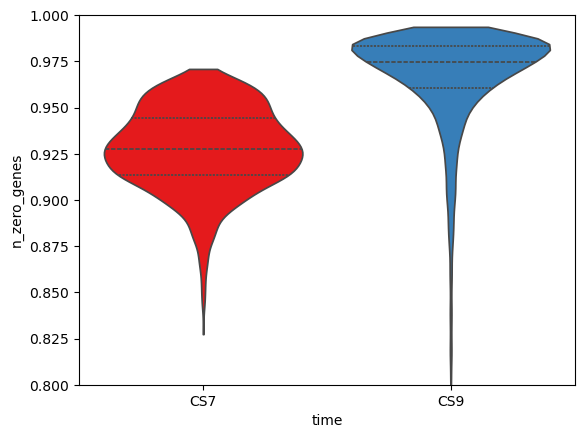

In [21]:
X = adata.X
zeros_per_cell = (X == 0).sum(axis=1)/len(adata.var.index)
adata.X.sum(axis = 1)
adata.obs['n_zero_genes'] = zeros_per_cell
sns.violinplot(
    x="time",
    y="n_zero_genes",
    data=adata.obs,
    palette="Set1",
    inner="quartile", 
    cut=0,
    saturation=1
)
plt.ylim(0.8, 1)

In [ ]:
non_zero_counts = adata.X.indptr[1:] - adata.X.indptr[:-1]
adata.obs['n_zero_genes'] = 1 - (non_zero_counts / len(adata.var.index))
sns.violinplot(
    x="time",
    y="n_zero_genes",
    data=adata.obs,
    palette="Set1",
    inner="quartile", 
    cut=0,
    saturation=1
)
# run this for sparse matrix

In [22]:
q_s = np.percentile(adata[adata.obs.s_e == 'start'].obs['n_zero_genes'], 50)
q_e = np.percentile(adata[adata.obs.s_e == 'end'].obs['n_zero_genes'], 50)

In [23]:
q_values = [q_s, q_e]
x = np.array(list(range(len(q_values))))
y = np.array(sorted(q_values))

## X calculation for input timepoints more than 2

In [ ]:
x_mean = np.mean(x)
y_mean = np.mean(y)
b = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean)**2)
a = y_mean - b * x_mean
y_pred = a + b * x_mean
y_pred_train = a + b * x
residuals = y - y_pred_train
sse = np.sum(residuals**2)
sigma_hat = np.sqrt(sse / (len(q_values) - 2))
se_pred = sigma_hat * np.sqrt(1 + 1/5 + (len(q_values) - 2 - x_mean)**2 / np.sum((x - x_mean)**2))

In [ ]:
a_vals = np.linspace(0.001, 0.95, 100)

t_crit_vals = stats.t.ppf(1 - a_vals/2, df=len(q_values)-2)
lower = y_pred - t_crit_vals * se_pred
upper = y_pred + t_crit_vals * se_pred

plt.figure(figsize=(7, 5))

upper[upper > 1] = 1.0
plt.plot(a_vals, lower, label='Lower bound', color='blue')
plt.plot(a_vals, upper, label='Upper bound', color='red')
a_mark = 0.5 # if multiple time points are involved, a_mark can be set larger with more strict statistical test
mask = a_vals >= a_mark
plt.fill_between(a_vals, lower, upper, where=mask, alpha=0.2, color='gray', interpolate=True, label='Prediction interval')

plt.axhline(y=y_pred, color='green', linestyle='--', linewidth=1.5, label=f'pred = {y_pred:.3f}')
plt.text(0.5, y_pred + 0.002, f'pred = {y_pred:.3f}', ha='right', va='bottom', fontsize=10, color='green')

t_mark = stats.t.ppf(1 - a_mark/2, df=3)
low_mark = y_pred - t_mark * se_pred
up_mark = y_pred + t_mark * se_pred

plt.scatter(a_mark, low_mark, s=50, color='blue', edgecolors='k', zorder=5)
plt.scatter(a_mark, up_mark, s=50, color='red', edgecolors='k', zorder=5)
plt.legend(loc='lower right', fontsize=9, framealpha=0.8)
plt.xlabel('Significance level α')
plt.ylabel('Dropout rate (%)')
plt.title('Prediction interval of dropout rate vs. α')
plt.grid(True, alpha=0.3)

plt.text(a_mark, low_mark - 0.012, f'({a_mark:.2f}, {low_mark:.3f})', 
         ha='center', fontsize=9, color='blue')
plt.text(a_mark, up_mark + 0.012, f'({a_mark:.2f}, {up_mark:.3f})', 
         ha='center', fontsize=9, color='red')
plt.show()

In [56]:
cell_orders = preprocess_cell_orders(adata_interpolated)
X_candidates = np.arange(10000, 20001, 500)
dropout_medians = []

for X in X_candidates:
    med = median_dropout_for_X(cell_orders, X)
    dropout_medians.append(med)

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(X_candidates, dropout_medians, 'o-', color='orange', label='Median dropout rate', markersize=3)

plt.axhline(y=y_pred, color='green', linestyle='--', label=f'Predicted median = {y_pred:.3f}', alpha=0.9)
plt.axhline(y=up_mark, color='red', linestyle='-', label=f'Upper bound = {up_mark:.3f}', alpha=0.5)
plt.axhline(y=low_mark, color='blue', linestyle='-', label=f'Lower bound = {low_mark:.3f}', alpha=0.5)

f_interp = interp1d(dropout_medians, X_candidates, kind='linear', bounds_error=False, fill_value=(X_candidates[0], X_candidates[-1]))
X_at_lower = f_interp(low_mark)
X_at_upper = f_interp(up_mark)
X_at_pred = f_interp(y_pred)

if not np.isnan(X_at_lower):
    plt.scatter(X_at_lower, low_mark, color='blue', zorder=5, marker='s', alpha=0.75)
    plt.text(X_at_lower, low_mark-0.01, f'X={X_at_lower:.0f}', ha='center', fontsize=8)
if not np.isnan(X_at_upper):
    plt.scatter(X_at_upper, up_mark, color='red', zorder=5, marker='s', alpha=0.75)
    plt.text(X_at_upper, up_mark+0.01, f'X={X_at_upper:.0f}', ha='center', fontsize=8)
if not np.isnan(X_at_pred):
    plt.scatter(X_at_pred, y_pred, color='green', zorder=5, marker='s', alpha=0.75)
    plt.text(X_at_pred, y_pred-0.015, f'X={X_at_pred:.0f}', ha='center', fontsize=8, color='green')

if not np.isnan(X_at_lower) and not np.isnan(X_at_upper):
    X_min = min(X_at_lower, X_at_upper)
    X_max = max(X_at_lower, X_at_upper)
    plt.axvspan(X_min, X_max, alpha=0.2, color='gray', label=f'Reasonable X: [{X_min:.0f}, {X_max:.0f}]')

plt.xlabel('Initial scale total UMI (X)')
plt.ylabel('Median dropout rate')
plt.title('Dropout rate vs. initial scale X')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## X calculation for 2 input timepoints

In [24]:
x_mean = np.mean(x)
y_mean = np.mean(y)
y_pred = y_mean

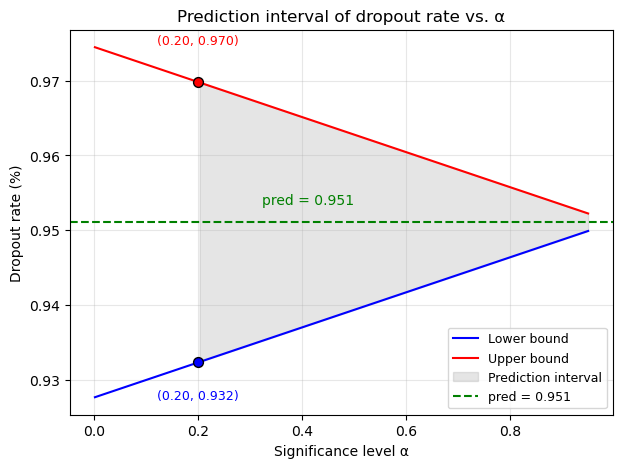

In [25]:
a_vals = np.linspace(0.001, 0.95, 100)
data_range = max(q_s, q_e) - min(q_s, q_e)
width = data_range * (1 - a_vals)

lower = y_pred - width / 2
upper = y_pred + width / 2

plt.figure(figsize=(7, 5))

upper[upper > 1] = 1.0
plt.plot(a_vals, lower, label='Lower bound', color='blue')
plt.plot(a_vals, upper, label='Upper bound', color='red')
a_mark = 0.2 # if only 2 time points are involved, a_mark should be set lower with less strict statistical test
mask = a_vals >= a_mark
plt.fill_between(a_vals, lower, upper, where=mask, alpha=0.2, color='gray', interpolate=True, label='Prediction interval')

plt.axhline(y=y_pred, color='green', linestyle='--', linewidth=1.5, label=f'pred = {y_pred:.3f}')
plt.text(0.5, y_pred + 0.002, f'pred = {y_pred:.3f}', ha='right', va='bottom', fontsize=10, color='green')

low_mark = y_pred - (data_range * (1 - a_mark)) / 2
up_mark = y_pred + (data_range * (1 - a_mark)) / 2
low_mark = np.clip(low_mark, min(q_s, q_e), max(q_s, q_e))
up_mark = np.clip(up_mark, min(q_s, q_e), max(q_s, q_e))

plt.scatter(a_mark, low_mark, s=50, color='blue', edgecolors='k', zorder=5)
plt.scatter(a_mark, up_mark, s=50, color='red', edgecolors='k', zorder=5)
plt.legend(loc='lower right', fontsize=9, framealpha=0.8)
plt.xlabel('Significance level α')
plt.ylabel('Dropout rate (%)')
plt.title('Prediction interval of dropout rate vs. α')
plt.grid(True, alpha=0.3)

plt.text(a_mark, low_mark - 0.005, f'({a_mark:.2f}, {low_mark:.3f})', 
         ha='center', fontsize=9, color='blue')
plt.text(a_mark, up_mark + 0.005, f'({a_mark:.2f}, {up_mark:.3f})', 
         ha='center', fontsize=9, color='red')
plt.show()

In [29]:
cell_orders = preprocess_cell_orders(adata_interpolated)
X_candidates = np.arange(40001, 110001, 2000)
dropout_medians = []

for X in X_candidates:
    med = median_dropout_for_X(cell_orders, X)
    dropout_medians.append(med)

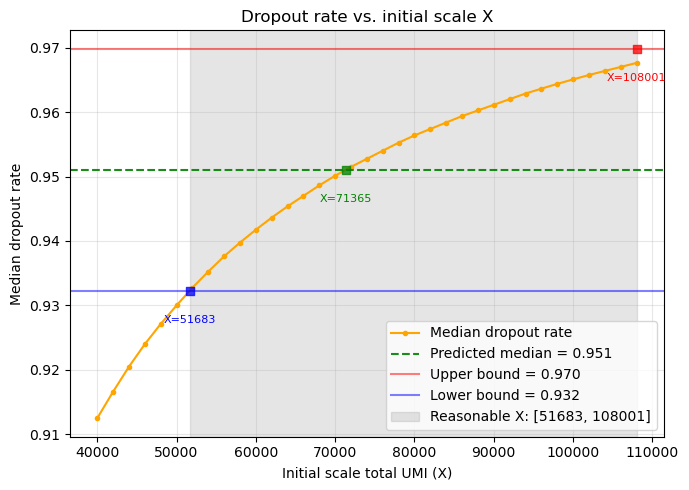

In [30]:
plt.figure(figsize=(7, 5))
plt.plot(S_candidates, dropout_medians, 'o-', color='orange', label='Median dropout rate', markersize=3)

plt.axhline(y=y_pred, color='green', linestyle='--', label=f'Predicted median = {y_pred:.3f}', alpha=0.9)
plt.axhline(y=up_mark, color='red', linestyle='-', label=f'Upper bound = {up_mark:.3f}', alpha=0.5)
plt.axhline(y=low_mark, color='blue', linestyle='-', label=f'Lower bound = {low_mark:.3f}', alpha=0.5)

f_interp = interp1d(dropout_medians, X_candidates, kind='linear', bounds_error=False, fill_value=(X_candidates[0], X_candidates[-1]))
X_at_lower = f_interp(low_mark)
X_at_upper = f_interp(up_mark)
X_at_pred = f_interp(y_pred)

if not np.isnan(X_at_lower):
    plt.scatter(X_at_lower, low_mark, color='blue', zorder=5, marker='s', alpha=0.75)
    plt.text(X_at_lower, low_mark-0.005, f'X={X_at_lower:.0f}', ha='center', fontsize=8, color='blue')
if not np.isnan(X_at_upper):
    plt.scatter(X_at_upper, up_mark, color='red', zorder=5, marker='s', alpha=0.75)
    plt.text(X_at_upper, up_mark-0.005, f'X={X_at_upper:.0f}', ha='center', fontsize=8, color='red')
if not np.isnan(X_at_pred):
    plt.scatter(X_at_pred, y_pred, color='green', zorder=5, marker='s', alpha=0.75)
    plt.text(X_at_pred, y_pred-0.005, f'X={X_at_pred:.0f}', ha='center', fontsize=8, color='green')

if not np.isnan(X_at_lower) and not np.isnan(X_at_upper):
    X_min = min(X_at_lower, X_at_upper)
    X_max = max(X_at_lower, X_at_upper)
    plt.axvspan(X_min, X_max, alpha=0.2, color='gray', label=f'Reasonable X: [{X_min:.0f}, {X_max:.0f}]')

plt.xlabel('Initial scale total UMI (X)')
plt.ylabel('Median dropout rate')
plt.title('Dropout rate vs. initial scale X')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_40220/3744400140.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


(0.8, 1.0)

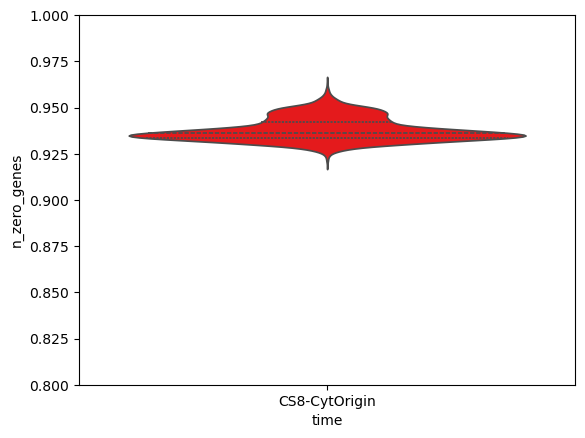

In [35]:
# This cell is intended for single execution.
# To regenerate adata_interpolated after target_sum changes, execute the reset cell (labeled 'generate or reset adata_interpolated') before running this cell again.

sc.pp.normalize_total(adata_interpolated, target_sum=5.5e4) # target_sum is the calculated X
adata_interpolated.X = reduce_total_expression(adata_interpolated.X, target_sum=1e4)

X = adata_interpolated.X
zeros_per_cell = (X == 0).sum(axis=1)/len(adata_interpolated.var.index)
adata_interpolated.X.sum(axis = 1)
adata_interpolated.obs['n_zero_genes'] = zeros_per_cell

sns.violinplot(
    x="time",
    y="n_zero_genes",
    data=adata_interpolated.obs,
    palette="Set1",
    inner="quartile",
    cut=2,
    saturation=1
)
plt.ylim(0.8, 1)

In [ ]:
adata_interpolated.write_h5ad()